<a href="https://colab.research.google.com/github/albertfast/loguru-dagster/blob/main/loguru_bridge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔥 Forging the Ultimate Loguru-Dagster Bridge

**Author**: Ahmet Sahiner, Abas Mohamed, Harold Symons  
**Goal**: Replace Dagster’s standard logging with Loguru for a clean, consistent, and developer-friendly experience everywhere.

## 🧩 The Challenge: Why Build a Bridge?

Dagster uses Python’s built-in `logging` module. While functional, it lacks the rich, out-of-the-box experience that Loguru provides. I wanted to fix this by achieving:

- ✨ **Beautiful Formatting**: Rich, colorful logs that are easy to read.
- 💡 **Smart Context**: Automatic inclusion of file, function, and line number.
- 🔗 **Universal Consistency**: The same beautiful log format in the terminal, the Dagster UI, and inside Docker containers.

To achieve this, we will build a three-part bridge that:
1.  Redirects all standard Python `logging` calls to Loguru.
2.  Configures a single, beautiful format for all logs.
3.  Temporarily replaces `context.log` with a Loguru-powered version during step execution.

## ⚙️ Step 1: The `InterceptHandler` — The Universal Translator

First, we need to capture every log message generated by the standard `logging` module. This includes logs from Dagster's core and any third-party libraries. We create a custom handler that forwards everything to Loguru.

In [ ]:
import logging
from loguru import logger

class InterceptHandler(logging.Handler):
    """Forwards all standard logging records to the Loguru sink."""
    def emit(self, record: logging.LogRecord) -> None:
        try:
            level = logger.level(record.levelname).name
        except ValueError:
            level = record.levelno

        # Find the frame that originated the log call
        frame, depth = logging.currentframe(), 2
        while frame and frame.f_code.co_filename == logging.__file__:
            frame = frame.f_back
            depth += 1

        logger.opt(depth=depth, exception=record.exc_info).log(level, record.getMessage())

# This magic line hijacks the root logger and enables interception globally
logging.basicConfig(handlers=[InterceptHandler()], level=0, force=True)

ModuleNotFoundError: No module named 'loguru'

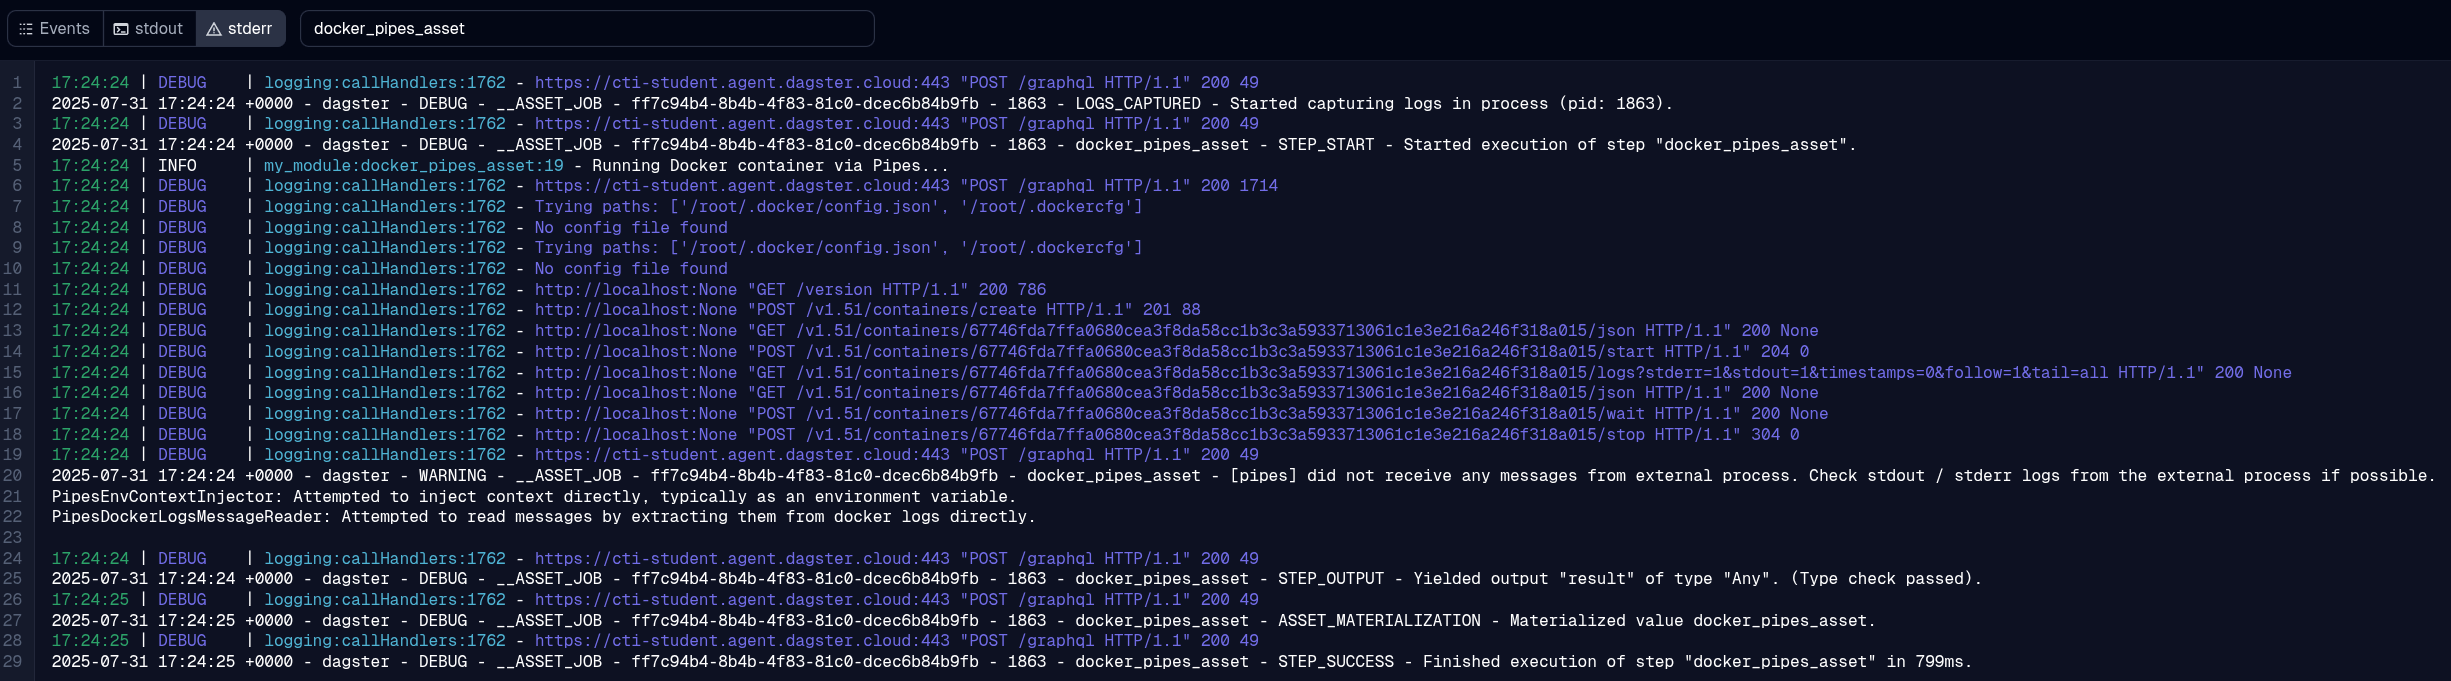

🔍 **Explanation**: By running `logging.basicConfig` with `force=True`, we replace all existing handlers on Python's root logger. From this moment on, every `logging.info`, `logging.warning`, etc., call is rerouted through our `InterceptHandler` and passed to Loguru.

## 🎨 Step 2: The `LoguruConfigurator` — The Director of Style

Now that all logs flow to Loguru, we need to configure how they look. This class sets up a single, beautiful sink that works everywhere.

In [ ]:
import sys
import os
from typing import Any

class LoguruConfigurator:
    """Configures a single, rich sink for Loguru, overridable by environment variables."""
    def __init__(self, enable_terminal_sink: bool = True):
        if getattr(LoguruConfigurator, "_initialized", False):
            return
        self.config = self._load_config()
        if enable_terminal_sink:
            self._setup_sinks()
        LoguruConfigurator._initialized = True

    def _load_config(self) -> dict[str, Any]:
        default_format = (
            "<green>{time:HH:mm:ss}</green> | <level>{level: <8}</level> | "
            "<cyan>{name}:{function}:{line}</cyan> - <level>{message}</level>"
        )
        return {
            "enabled": os.getenv("DAGSTER_LOGURU_ENABLED", "true").lower() in ("true", "1", "yes"),
            "log_level": os.getenv("DAGSTER_LOGURU_LOG_LEVEL", "DEBUG"),
            "format": os.getenv("DAGSTER_LOGURU_FORMAT", default_format),
        }

    def _setup_sinks(self) -> None:
        from loguru import logger
        logger.remove()
        # Write to stderr, which is captured by Dagster's UI and works in terminals.
        logger.add(sys.stderr, level=self.config["log_level"], format=self.config["format"], colorize=True)

# Instantiate the configurator once on import
loguru_config = LoguruConfigurator()

ModuleNotFoundError: No module named 'loguru'

🧠 **What this does**: It provides a zero-config experience by setting a great default format, but still allows advanced users to override it via environment variables. It's the best of both worlds.

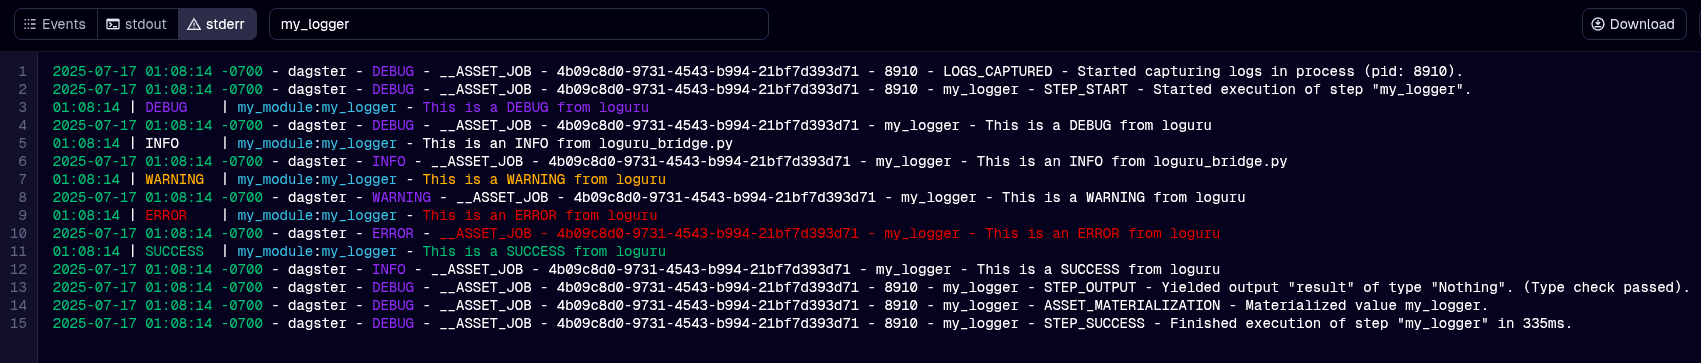

## ✨ Step 3: The `@with_loguru_logger` Decorator — The Final Polish

This is the final and most magical part. This decorator temporarily rewires `context.log` methods (like `.info`, `.debug`) to use Loguru **only during the execution of the decorated function**.

In [ ]:
from functools import wraps

def with_loguru_logger(fn):
    """A decorator that temporarily patches context.log to use Loguru."""
    @wraps(fn)
    def wrapper(*args, **kwargs):
        # Find the dagster context from the function's arguments
        context = kwargs.get("context", None)
        if context is None and args and hasattr(args[0], "log"):
            context = args[0]

        if not (context and hasattr(context, "log")):
            return fn(*args, **kwargs)

        # Save the original context.log methods to restore later
        original_log_methods = {
            name: getattr(context.log, name)
            for name in ["debug", "info", "warning", "error", "critical"]
        }

        # Create proxy functions that forward calls to loguru.logger
        def make_proxy(level):
            def proxy_fn(msg):
                logger.opt(depth=1).log(level, msg)
            return proxy_fn

        # Replace context.log methods with our new proxies
        for name, lvl in {
            "debug": "DEBUG", "info": "INFO", "warning": "WARNING",
            "error": "ERROR", "critical": "CRITICAL",
        }.items():
            setattr(context.log, name, make_proxy(lvl))

        try:
            # Run the actual asset/op code with the patched context
            return fn(*args, **kwargs)
        finally:
            # CRITICAL: Always restore the original methods, even if the function fails
            for name, orig in original_log_methods.items():
                setattr(context.log, name, orig)

    return wrapper

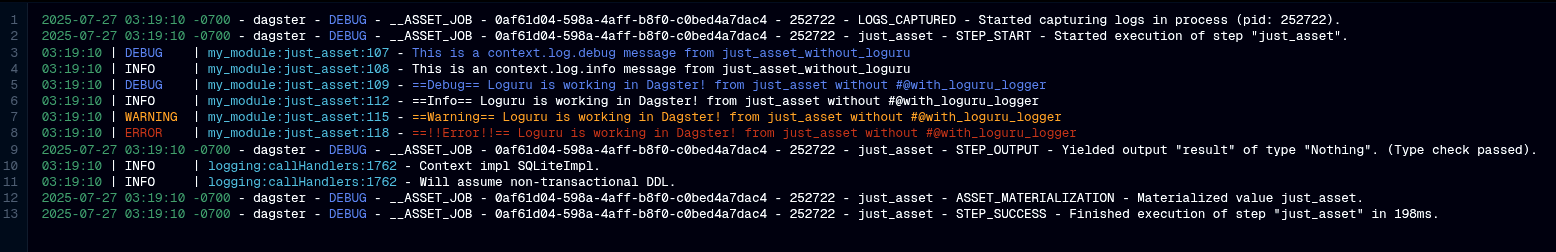

### 🔍 How It Works

This technique, often called "monkey-patching," is used carefully here. The `try...finally` block is crucial—it guarantees that we clean up after ourselves and restore the original methods, making our bridge a polite and safe guest in the Dagster ecosystem.

## 🚀 Real-World Example

Now, let's see it all come together in a Dagster asset.

In [ ]:
from dagster import asset

@asset
@with_loguru_logger
def demo_asset(context):
    # This now uses Loguru under the hood!
    context.log.info("This is a Loguru-powered log inside a Dagster asset.")

    # This also uses Loguru!
    logger.warning("This is a direct Loguru call, also captured.")

    print("Standard print statements remain unchanged.")

# To run this (assuming a mock context):
# demo_asset(context=...)

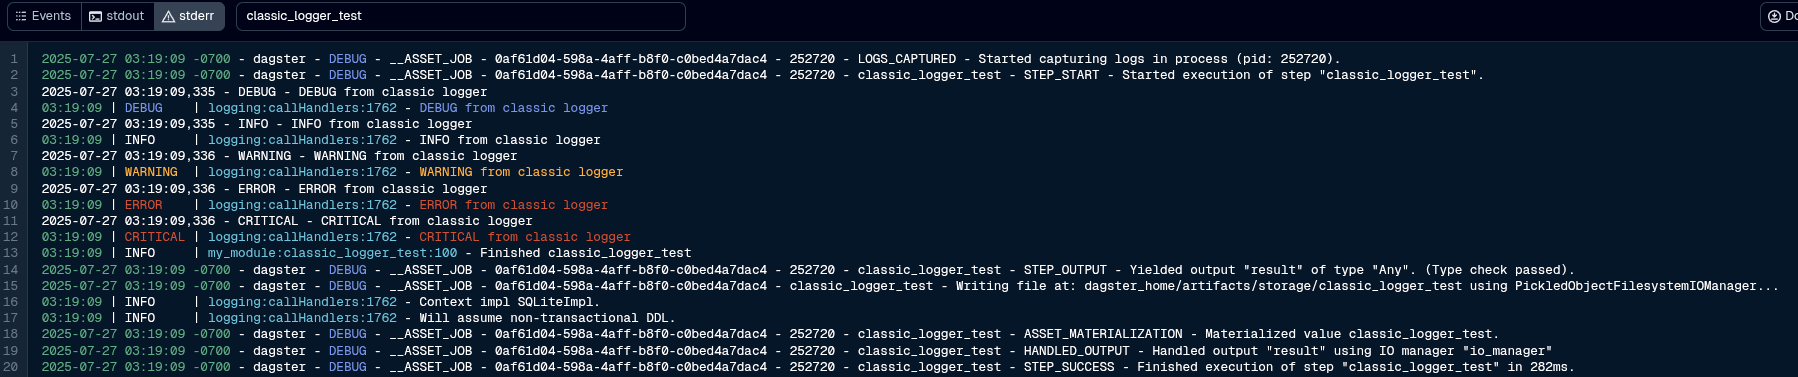

When you run this asset inside Dagster, you will see identical, Loguru-styled logs in both your **terminal** and inside the **Dagster UI** ✨.

## ✅ Conclusion

By combining these three components:

1.  **`InterceptHandler`**: Seamlessly captures every standard Python log.
2.  **`LoguruConfigurator`**: Beautifully styles every log with a rich, zero-config default.
3.  **`@with_loguru_logger`**: Elegantly bridges `context.log` calls into the same unified system.

...we have forged a complete and robust bridge that makes Loguru feel like a native, first-class citizen within the Dagster ecosystem.

This integration provides a clean, powerful, and fully stylized logging experience without requiring any complex setup from the user.

Enjoy beautiful logs, powered by Loguru and delivered seamlessly by Dagster. 🎉

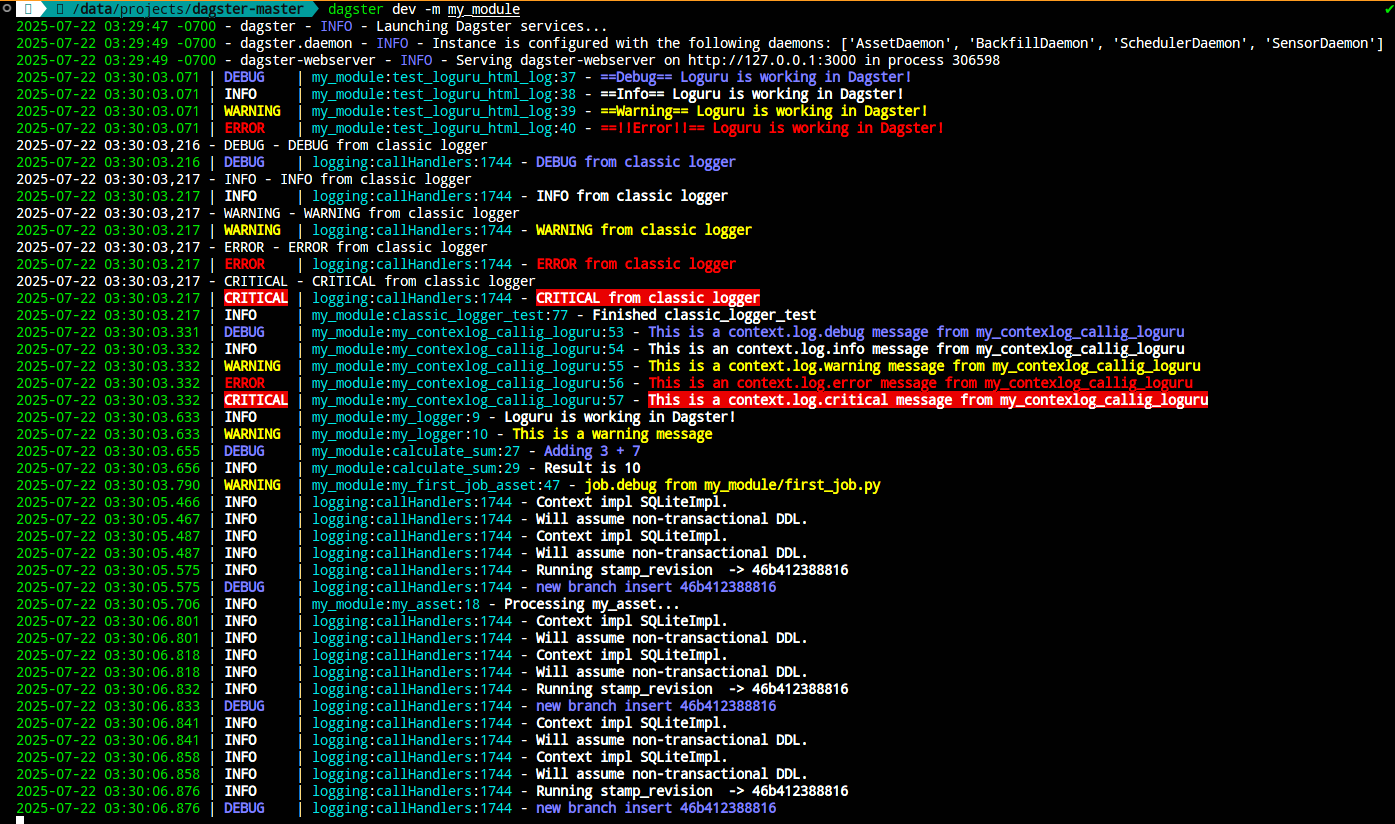